# RNA structure, geometry features, and sTASEP dynamics

This **methods / supplementary** notebook links three components used throughout **seq2ribo**:

1. **Minimum free energy (MFE) secondary structure** — *ViennaRNA* folding and a 2D nucleotide layout (MFE + `PLOT_TYPE_SIMPLE` + `get_xy_coordinates`, as in the structural exploration scripts).
2. **Geometry-derived inputs** — per-codon summaries that feed **sTASEP** and the **Mamba polisher** (angle deviation sum, pair count, positional bucket).
3. **Stochastic elongation (sTASEP)** — event-trace animations: **linear codon track** (baseline, baseline **+ four-channel wait residuals** as red/green arrows, high-initiation “traffic”), then the high-initiation trace on the **MFE 2D layout**, optionally **with wait-residual arrows** (§3c′). Illustrative only; production averages many runs.

**Data.** The CDS and observed A-site counts come from `notebooks/sample_data/demo_transcripts.pkl` (ribo-seq demo). The default entry is **ENST00000572154.1** (iPSC)—*not* the short test string from `try.py`. Change `DEMO_TX_ID` / `DEMO_CELL_LINE` to any other key in the pickle.

**Paths.** Locations are resolved relative to the **repository root** (folder containing `seq2ribo/` and `weights/`), whether Jupyter is started from the repo root or from `notebooks/`.

**Requirements.** ViennaRNA (`RNA`), `numpy`, `matplotlib`, `IPython`, and the `seq2ribo` package (for fitted rates and geometry binning). No GPU or PyTorch checkpoint is required for this notebook.



In [1]:
import math
import pickle
import random
import sys
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import RNA


def repo_root() -> Path:
    """Directory containing `seq2ribo/` and `weights/`."""
    cwd = Path.cwd().resolve()
    for base in [cwd, *cwd.parents]:
        if (base / "seq2ribo" / "__init__.py").is_file() and (base / "weights").is_dir():
            return base
    raise FileNotFoundError(
        "Could not locate repository root (need seq2ribo/ and weights/). "
        "Start Jupyter from the repo root or from notebooks/."
    )


REPO_ROOT = repo_root()
NOTEBOOK_DIR = REPO_ROOT / "notebooks"
SAMPLE_DATA = NOTEBOOK_DIR / "sample_data"
DEMO_CELL_LINE = "ipsc"
DEMO_TX_ID = "ENST00000572154.1"

DEMO_PICKLE = SAMPLE_DATA / "demo_transcripts.pkl"
if not DEMO_PICKLE.is_file():
    raise FileNotFoundError(f"Missing {DEMO_PICKLE}")

with open(DEMO_PICKLE, "rb") as f:
    _demo_db = pickle.load(f)

_lookup_key = None
for k in _demo_db:
    if k[0] == DEMO_CELL_LINE and _demo_db[k].get("tx_id") == DEMO_TX_ID:
        _lookup_key = k
        break
if _lookup_key is None:
    raise KeyError(f"No entry for cell_line={DEMO_CELL_LINE!r}, tx_id={DEMO_TX_ID!r}")

_rec = _demo_db[_lookup_key]
RNA_SEQ = _rec["sequence"].upper().replace("T", "U")
_gt_nuc = np.asarray(_rec["asite_counts"], dtype=np.float64)
assert len(_gt_nuc) == len(RNA_SEQ), "sequence and asite_counts length mismatch"

L_nt = len(RNA_SEQ)
assert L_nt % 3 == 0, "CDS length must be a multiple of 3"
L_cod = L_nt // 3
codons = [RNA_SEQ[i : i + 3] for i in range(0, L_nt, 3)]
gt_asite = _gt_nuc.reshape(-1, 3).sum(axis=1)

if str(REPO_ROOT) not in sys.path:
    sys.path.insert(0, str(REPO_ROOT))

from seq2ribo import constants as CONST
from seq2ribo.utils import CODON2IDX, DEFAULT_ANGLE_BINS, K_ANGLE_BINS, NONSTOP_IDX, STOP_CODONS, build_full_rate

_rates_map = {
    "hek293": (CONST.HEK293_RATES, CONST.HEK293_ALPHA, CONST.HEK293_BETA, CONST.HEK293_BUCKETS),
    "lcl": (CONST.LCL_RATES, CONST.LCL_ALPHA, CONST.LCL_BETA, CONST.LCL_BUCKETS),
    "rpe": (CONST.RPE_RATES, CONST.RPE_ALPHA, CONST.RPE_BETA, CONST.RPE_BUCKETS),
    "ipsc": (CONST.IPSC_RATES, CONST.IPSC_ALPHA, CONST.IPSC_BETA, CONST.IPSC_BUCKETS),
}
r_fit, alpha_vec, beta_vec, bucket_vec = _rates_map[DEMO_CELL_LINE.lower()]
rate = build_full_rate(r_fit)

print("Repository:", REPO_ROOT)
print("Transcript:", DEMO_TX_ID, "| cell line:", DEMO_CELL_LINE)
print("Codons:", L_cod, "| total A-site reads (ground truth):", int(gt_asite.sum()))


Repository: /mnt/disk90/user/gkaynar/seq2ribo
Transcript: ENST00000572154.1 | cell line: ipsc
Codons: 40 | total A-site reads (ground truth): 4898


## 1. MFE structure and 2D layout

MFE secondary structure via `RNA.fold_compound`; layout uses **ViennaRNA `PLOT_TYPE_SIMPLE`** (`get_xy_coordinates` on the MFE dot-bracket). This matches the structural phase plotting recipe. *Note:* `seq2ribo.geometry` uses **`PLOT_TYPE_TURTLE`** when caching features for inference, so raw angle sums can differ slightly from on-disk caches; **bin indices** remain aligned with the model.


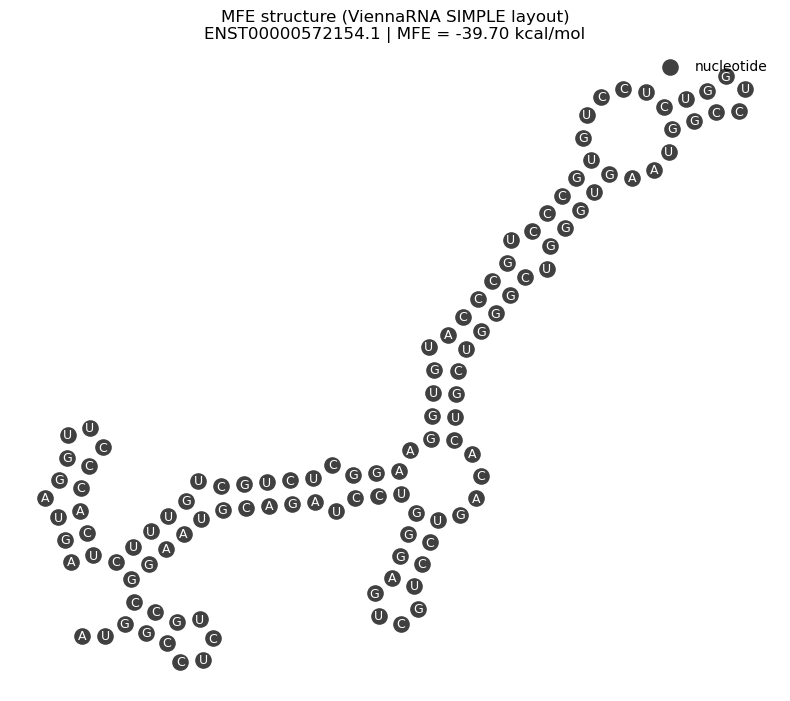

Dot-bracket (first 80 nt): ..(((....)))((((((((((.(((((((....))))....(((((((((.(((((...(((...))).....)))))....


In [2]:
fc = RNA.fold_compound(RNA_SEQ)
ss, mfe_energy = fc.mfe()

RNA.cvar.rna_plot_type = RNA.PLOT_TYPE_SIMPLE
coords = RNA.get_xy_coordinates(ss)

xs, ys = [], []
for i in range(L_nt):
    p = coords.get(i)
    xs.append(p.X)
    ys.append(p.Y)

fig, ax = plt.subplots(figsize=(8, 8))
ax.scatter(xs, ys, s=120, color="0.25", zorder=2, label="nucleotide")
for i, (x, y) in enumerate(zip(xs, ys)):
    ax.text(x, y, RNA_SEQ[i], fontsize=9, ha="center", va="center", color="white", zorder=3)
ax.set_aspect("equal", adjustable="box")
ax.axis("off")
ax.set_title(
    f"MFE structure (ViennaRNA SIMPLE layout)\n{DEMO_TX_ID} | MFE = {mfe_energy:.2f} kcal/mol"
)
ax.legend(loc="upper right", frameon=False)
plt.tight_layout()
plt.show()
print("Dot-bracket (first 80 nt):", ss[:80] + ("..." if len(ss) > 80 else ""))


## 2. Per-codon geometry features (sTASEP / polisher inputs)

**Angle:** interior vertex angle (rad) at each nucleotide along the 2D backbone; zeros at termini; **summed per codon** → `angle_dev_sum`. **Pair:** MFE `ptable`, binary paired/unpaired per nucleotide, **summed per codon**, clipped to [0, 3]. **Bucket:** first / middle / last third of the CDS (same rule as `Seq2Ribo`).


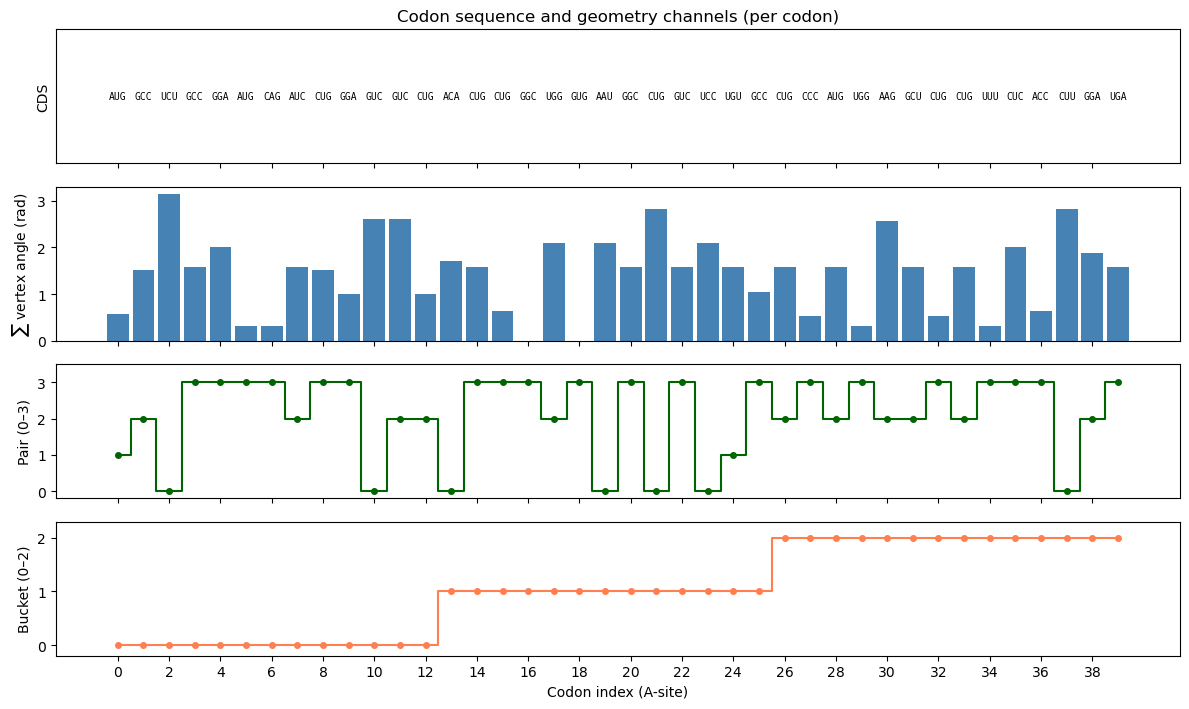

codon  angle_sum   ang_bin  pair  bucket
  0     0.5712     0       1      0
  1     1.5232     1       2      0
  2     3.1416     2       0      0
  3     1.5708     1       3      0
  4     1.9992     1       3      0
  5     0.3142     0       3      0
  6     0.3142     0       3      0
  7     1.5708     1       2      0
  8     1.5232     1       3      0
  9     0.9996     0       3      0
 10     2.6180     2       0      0
 11     2.6180     2       2      0
 12     0.9996     0       2      0
 13     1.7136     1       0      1
 14     1.5708     1       3      1
 15     0.6283     0       3      1
 16     0.0000     0       3      1
 17     2.0944     2       2      1
 18     0.0000     0       3      1
 19     2.0944     1       0      1
 20     1.5708     1       3      1
 21     2.8274     2       0      1
 22     1.5708     1       3      1
 23     2.0944     1       0      1
 24     1.5708     1       1      1
 25     1.0472     0       3      1
 26     1.5708     1   

In [3]:
def vertex_angles_per_nt(xcoords, ycoords):
    vertex = []
    for i in range(1, len(xcoords) - 1):
        v1x = xcoords[i] - xcoords[i - 1]
        v1y = ycoords[i] - ycoords[i - 1]
        v2x = xcoords[i + 1] - xcoords[i]
        v2y = ycoords[i + 1] - ycoords[i]
        n1 = math.hypot(v1x, v1y)
        n2 = math.hypot(v2x, v2y)
        if n1 == 0 or n2 == 0:
            ang = 0.0
        else:
            dot = v1x * v2x + v1y * v2y
            cosang = max(-1.0, min(1.0, dot / (n1 * n2)))
            ang = math.acos(cosang)
        vertex.append(ang)
    vertex = [0.0, 0.0] + vertex
    if len(vertex) < L_nt:
        vertex += [0.0] * (L_nt - len(vertex))
    else:
        vertex = vertex[:L_nt]
    return vertex


va_nt = np.array(vertex_angles_per_nt(xs, ys), dtype=np.float64)
angle_dev_sum = np.add.reduceat(va_nt, np.arange(0, L_nt, 3))

pt = RNA.ptable(ss)
is_paired = np.array([1 if pt[i + 1] > 0 else 0 for i in range(L_nt)], dtype=np.int32)
pair_count = np.add.reduceat(is_paired, np.arange(0, L_nt, 3))
pair_count = np.clip(pair_count, 0, 3)

bucket_idx = np.zeros(L_cod, dtype=np.int64)
l1 = L_cod // 3
l2 = (2 * L_cod) // 3
bucket_idx[l1:l2] = 1
bucket_idx[l2:] = 2

angle_bin_id = np.digitize(angle_dev_sum, DEFAULT_ANGLE_BINS) - 1
angle_bin_id = np.clip(angle_bin_id, 0, K_ANGLE_BINS - 1)

fig, axes = plt.subplots(4, 1, figsize=(max(12, L_cod * 0.22), 7.2), sharex=True,
                        gridspec_kw={"height_ratios": [1, 1.15, 1, 1]})
xc = np.arange(L_cod)

axes[0].set_ylim(0, 1)
axes[0].set_yticks([])
for j, c in enumerate(codons):
    axes[0].text(j, 0.5, c, ha="center", va="center", fontsize=7, family="monospace")
axes[0].set_ylabel("CDS")
axes[0].set_title("Codon sequence and geometry channels (per codon)")

axes[1].bar(xc, angle_dev_sum, color="steelblue", width=0.85)
axes[1].set_ylabel(r"$\sum$ vertex angle (rad)")
axes[1].tick_params(axis="x", labelbottom=False)

axes[2].step(xc, pair_count, where="mid", color="darkgreen", linewidth=1.5)
axes[2].scatter(xc, pair_count, color="darkgreen", s=16, zorder=3)
axes[2].set_ylabel("Pair (0–3)")
axes[2].set_ylim(-0.2, 3.5)

axes[3].step(xc, bucket_idx, where="mid", color="coral", linewidth=1.5)
axes[3].scatter(xc, bucket_idx, color="coral", s=16, zorder=3)
axes[3].set_ylabel("Bucket (0–2)")
axes[3].set_xlabel("Codon index (A-site)")
axes[3].set_ylim(-0.2, 2.3)
axes[3].set_xticks(xc[:: max(1, L_cod // 20)])

plt.tight_layout()
plt.show()

print("codon  angle_sum   ang_bin  pair  bucket")
for i in range(L_cod):
    print(f"{i:3d}   {angle_dev_sum[i]:8.4f}     {int(angle_bin_id[i])}       {int(pair_count[i])}      {int(bucket_idx[i])}")


## 3. sTASEP: illustrative ribosome trajectories

Production code averages **many** runs (`simulate_many`). Each panel below uses **one** Monte Carlo trace recorded at **events** (initiation, elongation, termination). This is for **intuition**; use `Seq2Ribo.predict(..., task="riboseq")` for quantitative occupancy.

- **§3a — Linear track, baseline initiation:** codon index on the *x*-axis (same geometry as the stacked feature plots).
- **§3a′ — Baseline + residuals:** same trace as §3a; **red** (left) / **green** (right) arrows encode each channel’s **additive wait** vs its **mean** (codon / angle / pair / bucket).
- **§3b — Linear track, high initiation:** larger per-step initiation probability (not fitted to ribo-seq) so ribosomes **queue** behind the exclusion window.
- **§3c — 2D structure:** the **§3b** trace with ribosome markers placed on the **SIMPLE** MFE layout (middle nucleotide of each codon). Motion follows **5′→3′ sequence order** along the backbone path—a schematic link between TASEP and structure, not a physical ribosome path.
- **§3c′ — 2D + residuals:** same as §3c with **red/green** arrows along the local backbone tangent (four channels, offset perpendicular to the backbone).



In [4]:
from matplotlib import animation
from IPython.display import HTML

EXCLUSION = 3
EPS = 1e-12
INIT_P = 0.04
# Illustrative only: higher initiation shows ribosome "traffic" (not from fitted rates).
INIT_P_TRAFFIC = 0.30
MAX_FRAMES = min(400, 50 * L_cod)
MAX_FRAMES_TRAFFIC = min(600, max(MAX_FRAMES, min(8 * L_cod, 800)))
MAX_MICRO_STEPS = 400_000


def simulate_once_trace(
    codon_list,
    ang_sum,
    p_count,
    init_p,
    rate_arr,
    alpha_v,
    beta_v,
    bucket_v,
    ang_bins,
    max_frames=400,
    max_micro_steps=200_000,
    rng=None,
):
    if rng is None:
        rng = random
    Lloc = len(codon_list)

    def ahead_clear(occ, start_idx, gap):
        end = min(Lloc, start_idx + gap)
        if start_idx >= Lloc:
            return False
        return all(not occ[i] for i in range(start_idx, end))

    occ = [False] * Lloc
    ribos = []
    frames = [tuple(sorted(ribos))]
    completed = 0
    times = 200
    steps = 0

    def record():
        if len(frames) < max_frames:
            frames.append(tuple(sorted(ribos)))

    while times > 0 and steps < max_micro_steps:
        if completed > 10 and rng.random() < 0.1:
            times -= 1

        changed = False
        if rng.random() < init_p and codon_list[0] not in STOP_CODONS and ahead_clear(occ, 0, EXCLUSION + 1):
            ribos.append(0)
            occ[0] = True
            changed = True

        for idx in reversed(range(len(ribos))):
            pos = ribos[idx]
            if codon_list[pos] in STOP_CODONS:
                occ[pos] = False
                ribos.pop(idx)
                completed += 1
                changed = True
                continue
            if pos == Lloc - 1:
                occ[pos] = False
                ribos.pop(idx)
                completed += 1
                changed = True
                continue
            nxt = pos + 1
            if codon_list[nxt] in STOP_CODONS:
                occ[pos] = False
                ribos.pop(idx)
                completed += 1
                changed = True
                continue
            k = CODON2IDX.get(codon_list[pos])
            if k is None:
                occ[pos] = False
                ribos.pop(idx)
                completed += 1
                changed = True
                continue
            a = float(ang_sum[pos])
            kk = int(np.digitize(a, ang_bins) - 1)
            kk = max(0, min(kk, K_ANGLE_BINS - 1))
            b = int(p_count[pos])
            b = max(0, min(b, 3))
            if pos < Lloc // 3:
                bucket = 0
            elif pos < 2 * Lloc // 3:
                bucket = 1
            else:
                bucket = 2
            base_time = rate_arr[k]
            wait = base_time + float(alpha_v[kk]) + float(beta_v[b]) + float(bucket_v[bucket])
            eff_rate = 1.0 / max(wait, EPS)
            if rng.random() < eff_rate and ahead_clear(occ, nxt, EXCLUSION):
                ribos[idx] = nxt
                occ[pos] = False
                occ[nxt] = True
                changed = True

        if changed:
            record()
        steps += 1

    return frames, completed, steps


random.seed(42)
frames, n_completed, steps_used = simulate_once_trace(
    codons,
    angle_dev_sum,
    pair_count,
    INIT_P,
    rate,
    alpha_vec,
    beta_vec,
    bucket_vec,
    DEFAULT_ANGLE_BINS,
    max_frames=MAX_FRAMES,
    max_micro_steps=MAX_MICRO_STEPS,
    rng=random.Random(42),
)
print(
    f"[baseline INIT_P={INIT_P}] frames={len(frames)} | completed≈{n_completed} | micro-steps={steps_used}"
)

frames_traffic, n_completed_t, steps_t = simulate_once_trace(
    codons,
    angle_dev_sum,
    pair_count,
    INIT_P_TRAFFIC,
    rate,
    alpha_vec,
    beta_vec,
    bucket_vec,
    DEFAULT_ANGLE_BINS,
    max_frames=MAX_FRAMES_TRAFFIC,
    max_micro_steps=MAX_MICRO_STEPS,
    rng=random.Random(12345),
)
print(
    f"[traffic INIT_P_TRAFFIC={INIT_P_TRAFFIC}] frames={len(frames_traffic)} | completed≈{n_completed_t} | micro-steps={steps_t}"
)


[baseline INIT_P=0.04] frames=400 | completed≈80 | micro-steps=2338
[traffic INIT_P_TRAFFIC=0.3] frames=400 | completed≈158 | micro-steps=2091


In [5]:
INTERVAL_MS = 70

fig, ax = plt.subplots(figsize=(max(12, L_cod * 0.25), 3.2))
ax.set_xlim(-0.5, L_cod - 0.5)
ax.set_ylim(-0.55, 1.45)
ax.set_xlabel("Codon index (A-site)")
ax.set_yticks([0.0, 1.0])
ax.set_yticklabels(["Ribosomes", "CDS"])

for j, c in enumerate(codons):
    ax.text(j, 1.0, c, ha="center", va="center", fontsize=6, family="monospace", color="0.35")

scatter = ax.scatter([], [], s=120, c="crimson", zorder=5, label="A-site")
ax.legend(loc="upper right", frameon=True, framealpha=0.92)


def update(frame_idx):
    pos = list(frames[frame_idx])
    if not pos:
        scatter.set_offsets(np.empty((0, 2)))
    else:
        scatter.set_offsets(np.column_stack([pos, np.zeros(len(pos))]))
    ax.set_title(
        f"§3a  Linear track, baseline initiation — frame {frame_idx + 1}/{len(frames)} | ribosomes: {len(pos)}"
    )
    return (scatter,)


anim = animation.FuncAnimation(fig, update, frames=len(frames), interval=INTERVAL_MS, blit=False, repeat=True)
plt.close(fig)
HTML(anim.to_jshtml())


### §3a′ — Baseline trace with wait-time residuals (four channels)

Same **baseline** event trace as §3a (`frames`, `INIT_P`). At each ribosome’s **current codon**, we decompose the sTASEP **per-step wait** (same recipe as the simulator) into four additive pieces:

**codon** · `rate[k]` (fitted base wait for codon identity **k**) · **angle** · `α` for the discretized angle bin · **pair** · `β` for paired-nt count (0–3) · **bucket** · positional third of the CDS.

For each channel we subtract its **reference mean** (codon: mean over all **non-stop** codons in the fitted table; angle / pair / bucket: mean over their respective parameter vectors). **Residual > 0** ⇒ slower than that reference; **< 0** ⇒ faster.

**Encoding:** **red** arrow points **left** (5′→3′ “back”) with length proportional to the **extra wait** (positive residual). **green** arrow points **right** (“forward”) with length proportional to **wait saved** (negative residual magnitude). Four **horizontal** rows per occupied codon (top to bottom: codon, angle, pair, bucket). *Approximate* mapping: arrow length is linear in |residual| after scaling by the maximum |residual| seen anywhere in this trace for that channel (so lengths are comparable across frames).


In [6]:
from matplotlib.patches import FancyArrowPatch

from seq2ribo.utils import NONSTOP_IDX

# Reference means (same additive pieces as simulate_once_trace).
_mean_codon_wait = float(np.mean(rate[np.array(NONSTOP_IDX, dtype=np.intp)]))
_mean_alpha = float(np.mean(alpha_vec))
_mean_beta = float(np.mean(beta_vec))
_mean_bucket = float(np.mean(bucket_vec))


def wait_residuals_at_codon(pos: int):
    """Returns (d_codon, d_angle, d_pair, d_bucket) vs channel means; NaNs if not drawable."""
    if pos < 0 or pos >= L_cod:
        return None
    c = codons[pos]
    if c in STOP_CODONS:
        return None
    k = CODON2IDX.get(c)
    if k is None:
        return None
    a = float(angle_dev_sum[pos])
    kk = int(np.digitize(a, DEFAULT_ANGLE_BINS) - 1)
    kk = max(0, min(kk, K_ANGLE_BINS - 1))
    b = int(pair_count[pos])
    b = max(0, min(b, 3))
    if pos < L_cod // 3:
        bucket = 0
    elif pos < 2 * L_cod // 3:
        bucket = 1
    else:
        bucket = 2
    w0 = float(rate[k])
    w1 = float(alpha_vec[kk])
    w2 = float(beta_vec[b])
    w3 = float(bucket_vec[bucket])
    return (
        w0 - _mean_codon_wait,
        w1 - _mean_alpha,
        w2 - _mean_beta,
        w3 - _mean_bucket,
    )


# Max |residual| per channel over the whole baseline trace (for arrow scaling).
_max_abs = np.zeros(4, dtype=np.float64)
for fr in frames:
    for pos in fr:
        dv = wait_residuals_at_codon(pos)
        if dv is None:
            continue
        for j in range(4):
            _max_abs[j] = max(_max_abs[j], abs(dv[j]))
_max_abs = np.maximum(_max_abs, 1e-12)

ARROW_ROWS = np.array([-0.16, -0.24, -0.32, -0.40])
ROW_LABELS = ["codon", "angle", "pair", "bucket"]
MAX_ARROW_LEN_CODONS = 4.5

_interval_ms_arrows = 70
_fig_arrows, _ax_arrows = plt.subplots(figsize=(max(12, L_cod * 0.25), 4.2))
_ax_arrows.set_xlim(-0.5, L_cod - 0.5)
_ax_arrows.set_ylim(-0.52, 1.45)
_ax_arrows.set_xlabel("Codon index (A-site)")
_ax_arrows.set_yticks([0.0, 1.0])
_ax_arrows.set_yticklabels(["Ribosomes", "CDS"])

for j, c in enumerate(codons):
    _ax_arrows.text(j, 1.0, c, ha="center", va="center", fontsize=6, family="monospace", color="0.35")

_scatter_arrows = _ax_arrows.scatter([], [], s=120, c="crimson", zorder=6, label="A-site")
_ax_arrows.legend(loc="upper right", frameon=True, framealpha=0.92)

for y, lab in zip(ARROW_ROWS, ROW_LABELS):
    _ax_arrows.text(-0.45, y, lab, ha="right", va="center", fontsize=8, color="0.35", clip_on=False)

_arrow_artists = []


def _update_arrows(frame_idx):
    while _arrow_artists:
        _arrow_artists.pop().remove()
    pos_list = list(frames[frame_idx])
    if not pos_list:
        _scatter_arrows.set_offsets(np.empty((0, 2)))
    else:
        _scatter_arrows.set_offsets(np.column_stack([pos_list, np.zeros(len(pos_list))]))
    for pos in pos_list:
        dv = wait_residuals_at_codon(pos)
        if dv is None:
            continue
        for j in range(4):
            d = dv[j]
            if abs(d) <= 1e-15:
                continue
            mag = (abs(d) / _max_abs[j]) * MAX_ARROW_LEN_CODONS
            if d > 0:
                x1, x2 = pos, pos - mag
                color = "#c41e3a"
            else:
                x1, x2 = pos, pos + mag
                color = "#2e8b57"
            y = ARROW_ROWS[j]
            arr = FancyArrowPatch(
                (x1, y),
                (x2, y),
                arrowstyle="-|>",
                mutation_scale=10 + 6 * (abs(d) / _max_abs[j]),
                color=color,
                linewidth=1.25,
                zorder=4,
                shrinkA=0,
                shrinkB=0,
            )
            _ax_arrows.add_patch(arr)
            _arrow_artists.append(arr)
    _ax_arrows.set_title(
        f"§3a′  Baseline + wait residuals — frame {frame_idx + 1}/{len(frames)} | ribosomes: {len(pos_list)}"
    )
    return (_scatter_arrows,)


_anim_arrows = animation.FuncAnimation(
    _fig_arrows,
    _update_arrows,
    frames=len(frames),
    interval=_interval_ms_arrows,
    blit=False,
    repeat=True,
)
plt.close(_fig_arrows)
HTML(_anim_arrows.to_jshtml())



### §3b — Linear track, high initiation (traffic)

Same simulator as §3a with **`INIT_P_TRAFFIC`** (set in the previous cell). This exaggerates initiation so **several ribosomes** coexist and **queue** when the downstream exclusion zone is occupied. Tweak `INIT_P_TRAFFIC` if the trace is empty or too dense for long CDS.

In [7]:
INTERVAL_MS_TRAFFIC = 55

fig, ax = plt.subplots(figsize=(max(12, L_cod * 0.25), 3.2))
ax.set_xlim(-0.5, L_cod - 0.5)
ax.set_ylim(-0.55, 1.45)
ax.set_xlabel("Codon index (A-site)")
ax.set_yticks([0.0, 1.0])
ax.set_yticklabels(["Ribosomes", "CDS"])

for j, c in enumerate(codons):
    ax.text(j, 1.0, c, ha="center", va="center", fontsize=6, family="monospace", color="0.35")

scatter_t = ax.scatter([], [], s=120, c="crimson", zorder=5, label="A-site")
ax.legend(loc="upper right", frameon=True, framealpha=0.92)


def update_traffic(frame_idx):
    pos = list(frames_traffic[frame_idx])
    if not pos:
        scatter_t.set_offsets(np.empty((0, 2)))
    else:
        scatter_t.set_offsets(np.column_stack([pos, np.zeros(len(pos))]))
    ax.set_title(
        f"§3b  Linear track, high initiation — frame {frame_idx + 1}/{len(frames_traffic)} | ribosomes: {len(pos)}"
    )
    return (scatter_t,)


anim_traffic = animation.FuncAnimation(
    fig, update_traffic, frames=len(frames_traffic), interval=INTERVAL_MS_TRAFFIC, blit=False, repeat=True
)
plt.close(fig)
HTML(anim_traffic.to_jshtml())

### §3c — High-initiation trace on the MFE 2D layout

Ribosome markers use the **middle nucleotide** of each occupied codon on the **SIMPLE** coordinates from §1. **Gray curve:** backbone in **5′→3′ sequence order**; **light lines:** MFE base pairs. The animation replays **`frames_traffic`** from §3b so several ribosomes are usually visible.


In [8]:
def codon_to_asite_nt(ci: int) -> int:
    """Middle nucleotide (0-based index) of codon ci for A-site marker placement."""
    return int(min(3 * ci + 1, L_nt - 1))


INTERVAL_MS_2D = 55
fig, ax = plt.subplots(figsize=(9, 9))
ax.set_aspect("equal", adjustable="box")
ax.axis("off")

ax.plot(xs, ys, color="0.5", linewidth=1.5, zorder=1, alpha=0.95, label="Backbone (5′→3′)")

pt_anim = RNA.ptable(ss)
for i in range(L_nt):
    j = pt_anim[i + 1]
    if j <= 0:
        continue
    j0 = j - 1
    if i >= j0:
        continue
    ax.plot([xs[i], xs[j0]], [ys[i], ys[j0]], color="0.82", linewidth=0.85, zorder=0)

ax.scatter(xs, ys, s=32, c="0.93", edgecolors="0.45", linewidths=0.35, zorder=2)

mar = 0.06 * max(max(xs) - min(xs), max(ys) - min(ys), 1.0)
ax.set_xlim(min(xs) - mar, max(xs) + mar)
ax.set_ylim(min(ys) - mar, max(ys) + mar)

scatter_2d = ax.scatter(
    [],
    [],
    s=240,
    c="crimson",
    edgecolors="darkred",
    linewidths=1.1,
    zorder=6,
    label="A-site (codon middle nt)",
)


def update_2d(frame_idx):
    pos = list(frames_traffic[frame_idx])
    if not pos:
        scatter_2d.set_offsets(np.empty((0, 2)))
    else:
        ii = [codon_to_asite_nt(c) for c in pos]
        scatter_2d.set_offsets(np.column_stack([[xs[k] for k in ii], [ys[k] for k in ii]]))
    ax.set_title(
        f"§3c  MFE 2D layout — frame {frame_idx + 1}/{len(frames_traffic)} | ribosomes: {len(pos)}",
        fontsize=11,
    )
    return (scatter_2d,)


ax.legend(loc="lower right", frameon=True, framealpha=0.92, fontsize=9)
anim_2d = animation.FuncAnimation(
    fig, update_2d, frames=len(frames_traffic), interval=INTERVAL_MS_2D, blit=False, repeat=True
)
plt.close(fig)
HTML(anim_2d.to_jshtml())

Animation size has reached 21036008 bytes, exceeding the limit of 20971520.0. If you're sure you want a larger animation embedded, set the animation.embed_limit rc parameter to a larger value (in MB). This and further frames will be dropped.


### §3c′ — 2D layout + same wait-residual arrows (traffic trace)

Same **high-initiation** trace as §3c (`frames_traffic`). Ribosome **A-site** markers stay at the **middle nucleotide** of each codon. For each occupied codon we draw **four** arrows in the plane (rows **offset perpendicular** to the local 5′→3′ backbone tangent): **red** toward 5′ (slower-than-reference channel contribution), **green** toward 3′ (faster), with length ∝ |residual| after **per-channel** scaling by the max |residual| over **this** trace. Reference means match §3a′ (codon average over fitted non-stop table; angle / pair / bucket = mean of their vectors).


In [9]:
from matplotlib.patches import FancyArrowPatch

# --- Same residuals as §3a′ (self-contained if that cell was skipped) ---
_mean_codon_wait_2d = float(np.mean(rate[np.array(NONSTOP_IDX, dtype=np.intp)]))
_mean_alpha_2d = float(np.mean(alpha_vec))
_mean_beta_2d = float(np.mean(beta_vec))
_mean_bucket_2d = float(np.mean(bucket_vec))


def wait_residuals_at_codon_2d(pos: int):
    if pos < 0 or pos >= L_cod:
        return None
    c = codons[pos]
    if c in STOP_CODONS:
        return None
    k = CODON2IDX.get(c)
    if k is None:
        return None
    a = float(angle_dev_sum[pos])
    kk = int(np.digitize(a, DEFAULT_ANGLE_BINS) - 1)
    kk = max(0, min(kk, K_ANGLE_BINS - 1))
    b = int(pair_count[pos])
    b = max(0, min(b, 3))
    if pos < L_cod // 3:
        bucket = 0
    elif pos < 2 * L_cod // 3:
        bucket = 1
    else:
        bucket = 2
    w0 = float(rate[k])
    w1 = float(alpha_vec[kk])
    w2 = float(beta_vec[b])
    w3 = float(bucket_vec[bucket])
    return (
        w0 - _mean_codon_wait_2d,
        w1 - _mean_alpha_2d,
        w2 - _mean_beta_2d,
        w3 - _mean_bucket_2d,
    )


_max_abs_2d = np.zeros(4, dtype=np.float64)
for fr in frames_traffic:
    for pos in fr:
        dv = wait_residuals_at_codon_2d(pos)
        if dv is None:
            continue
        for j in range(4):
            _max_abs_2d[j] = max(_max_abs_2d[j], abs(dv[j]))
_max_abs_2d = np.maximum(_max_abs_2d, 1e-12)


def backbone_tangent_nt(nt: int):
    """Unit vector 5'->3' (~ toward nt+1) in SIMPLE layout coordinates."""
    if nt < L_nt - 1:
        vx, vy = xs[nt + 1] - xs[nt], ys[nt + 1] - ys[nt]
    elif nt > 0:
        vx, vy = xs[nt] - xs[nt - 1], ys[nt] - ys[nt - 1]
    else:
        vx, vy = 1.0, 0.0
    nrm = math.hypot(vx, vy)
    if nrm < 1e-12:
        return (1.0, 0.0)
    return (vx / nrm, vy / nrm)


_span_2d = max(max(xs) - min(xs), max(ys) - min(ys), 1.0)
_lane_sep_2d = 0.014 * _span_2d
_MAX_ARROW_LEN_2D = 0.085 * _span_2d

_fig_2da, _ax_2da = plt.subplots(figsize=(9, 9))
_ax_2da.set_aspect("equal", adjustable="box")
_ax_2da.axis("off")

_ax_2da.plot(xs, ys, color="0.5", linewidth=1.5, zorder=1, alpha=0.95, label="Backbone (5′→3′)")

_pt_2da = RNA.ptable(ss)
for i in range(L_nt):
    j = _pt_2da[i + 1]
    if j <= 0:
        continue
    j0 = j - 1
    if i >= j0:
        continue
    _ax_2da.plot([xs[i], xs[j0]], [ys[i], ys[j0]], color="0.82", linewidth=0.85, zorder=0)

_ax_2da.scatter(xs, ys, s=32, c="0.93", edgecolors="0.45", linewidths=0.35, zorder=2)

_mar_2da = 0.06 * _span_2d
_ax_2da.set_xlim(min(xs) - _mar_2da, max(xs) + _mar_2da)
_ax_2da.set_ylim(min(ys) - _mar_2da, max(ys) + _mar_2da)

_scatter_2da = _ax_2da.scatter(
    [],
    [],
    s=240,
    c="crimson",
    edgecolors="darkred",
    linewidths=1.1,
    zorder=7,
    label="A-site",
)
_arrow_artists_2d = []


def _update_2d_arrows(frame_idx):
    while _arrow_artists_2d:
        _arrow_artists_2d.pop().remove()
    pos_list = list(frames_traffic[frame_idx])
    if not pos_list:
        _scatter_2da.set_offsets(np.empty((0, 2)))
    else:
        ii = [codon_to_asite_nt(c) for c in pos_list]
        _scatter_2da.set_offsets(np.column_stack([[xs[k] for k in ii], [ys[k] for k in ii]]))
    for pos in pos_list:
        nt = codon_to_asite_nt(pos)
        tx, ty = backbone_tangent_nt(nt)
        nx, ny = -ty, tx
        dv = wait_residuals_at_codon_2d(pos)
        if dv is None:
            continue
        for j in range(4):
            d = dv[j]
            if abs(d) <= 1e-15:
                continue
            mag = (abs(d) / _max_abs_2d[j]) * _MAX_ARROW_LEN_2D
            off = _lane_sep_2d * (j - 1.5)
            px = xs[nt] + nx * off
            py = ys[nt] + ny * off
            if d > 0:
                x1, y1 = px, py
                x2, y2 = px - mag * tx, py - mag * ty
                color = "#c41e3a"
            else:
                x1, y1 = px, py
                x2, y2 = px + mag * tx, py + mag * ty
                color = "#2e8b57"
            arr = FancyArrowPatch(
                (x1, y1),
                (x2, y2),
                arrowstyle="-|>",
                mutation_scale=8 + 5 * (abs(d) / _max_abs_2d[j]),
                color=color,
                linewidth=1.15,
                zorder=5,
                shrinkA=0,
                shrinkB=0,
            )
            _ax_2da.add_patch(arr)
            _arrow_artists_2d.append(arr)
    _ax_2da.set_title(
        f"§3c′  MFE 2D + wait residuals — frame {frame_idx + 1}/{len(frames_traffic)} | ribosomes: {len(pos_list)}",
        fontsize=11,
    )
    return (_scatter_2da,)


_ax_2da.legend(loc="lower right", frameon=True, framealpha=0.92, fontsize=9)
# Compact legend for arrow encoding (matplotlib patch handles only; use text box)
_leg_txt = "Arrows (offset ⊥ backbone): red → 5′ (slower), green → 3′ (faster); rows: codon, angle, pair, bucket"
_ax_2da.text(
    0.02,
    0.98,
    _leg_txt,
    transform=_ax_2da.transAxes,
    fontsize=8,
    va="top",
    ha="left",
    color="0.2",
    bbox=dict(boxstyle="round,pad=0.35", facecolor="white", edgecolor="0.75", alpha=0.9),
)

_anim_2da = animation.FuncAnimation(
    _fig_2da,
    _update_2d_arrows,
    frames=len(frames_traffic),
    interval=55,
    blit=False,
    repeat=True,
)
plt.close(_fig_2da)
HTML(_anim_2da.to_jshtml())



Animation size has reached 21025252 bytes, exceeding the limit of 20971520.0. If you're sure you want a larger animation embedded, set the animation.embed_limit rc parameter to a larger value (in MB). This and further frames will be dropped.
